# PTB-XL — Exploratory Data Analysis

Groundwork for the tokenizer comparison: **fixed temporal patches vs RR/beat-oriented tokens** for self-supervised ECG representation learning.

This notebook is exploratory. Every non-trivial operation it performs — label mapping, fold handling, provenance accounting, cohort filtering — is imported from `ecg.data`, so that no number shown here is produced by code the experiments do not also use.

---

## Facts that drive the design

*Measured below on 21,799 records from 18,869 patients. Section references point at the cell that produces each number.*

### The data

1. **The published `strat_fold` split is patient-disjoint — verified, not trusted (§2).** 2,111 patients (11.2%) contribute more than one recording, up to 10 each, so a record-level random split would put the same heart in train and test. The published folds pass: zero patient overlap between train (15,023 patients), val (1,942) and test (1,904). We use them verbatim.

2. **Folds 9 and 10 are 100% human-validated; the training folds are only ~67% (§5).** PTB-XL deliberately reserved its best annotations for the last two folds. About **33% of training records carry machine-generated labels no person ever checked, against 0% in val and test**. Only **12 cardiologists** validated the entire dataset. This single fact drives the cohort decision in §11.

3. **Machine-only annotation is not spread evenly across classes (§5).** NORM 17.6% but MI 36.4%, HYP 32.2%, and unlabelled records 60.8%. Removing unvalidated records is therefore not a neutral cleanup — it reshapes the class balance at the same time (§11 measures by how much).

4. **Labels are multi-label, not multi-class (§4).** 23.6% of records carry 2+ superclasses, up to 4. Accuracy is meaningless; the loss is per-class binary cross-entropy, never softmax, and every metric is macro-averaged over the 5 classes.

5. **Class imbalance spans 1:1.3 to 1:7.2 (§4).** NORM 43.6%, MI 25.1%, STTC 24.0%, CD 22.5%, HYP 12.2%. HYP is what will move macro PR-AUC, and PR-AUC is far more sensitive to this than AUROC.

6. **NORM is almost exclusive; the pathologies are not (§4).** NORM co-occurs with MI exactly **once** in 21,799 records — but MI∩CD is 1,794 and STTC∩HYP is 1,509. The label space is close to "healthy, or some combination of four pathologies".

7. **Fold-to-fold prevalence drift is small: at most 1.57 percentage points (§3).** The folds are genuinely comparable, so a train/test gap in results will not be explainable by class balance alone.

8. **`scp_codes` likelihood `0.0` means "asserted, confidence unquantified" — not "absent" (§4).** 47.5% of all statements sit at exactly 0.0; thresholding at 100 would discard 19% of labelled records. Threshold stays at 0.0.

9. **Ages above 89 are stored as the sentinel `300` (§6)** — 293 records. Naïve mean age 62.8 years; correct value 59.5.

### The cohorts (§11)

10. **SSL pretraining uses all 17,418 records in folds 1–8, unfiltered.** Pretraining needs no labels, so weak, absent or contradictory annotation is irrelevant to it. Folds 9 and 10 are excluded outright — pretraining on held-out waveforms would leak them.

11. **Supervised training drops to 11,261 records (−35.3%, 15,023 → 10,255 patients)** after excluding pacemaker, electrode-problem, non-human-validated, unlabelled, and NORM+pathology records. The filter touches the training split only; val and test stay whole at 2,183 and 2,198. All 6,157 removals go to a manifest, and **88% of them are `not_validated_by_human` alone**.

12. **The filter's real cost is a class-prior shift (§11).** NORM in training rises from 43.6% to **49.8%** while test stays at 43.8% — a **+5.99 pp** gap where the raw split had 0.33 pp. MI falls to 21.1% against test's 25.0%, CD to 20.5% against 22.6%. The model trains on a population measurably healthier than the one it is scored on. Two things contain it: F1 thresholds are picked on the *unfiltered* fold 9, so threshold selection sees the true prior; and AUROC/PR-AUC are rank-based. It applies identically to all four arms, so the comparison stays fair.

13. **The "contradictory" NORM+pathology labels are mostly deliberate, not noise (§11).** 445 records dataset-wide, of which **91.5% are the single combination NORM+CD** and **88.1% were human-validated**. That pattern reads as annotators recording "normal apart from a conduction finding", a routine clinical statement — not sloppiness. They are excluded anyway, because NORM and a pathology on one record give the model two incompatible gradients and there is no way to tell which to trust. But this is a judgement call about the label space, recorded as such, and it is what moves the CD prior by −2 pp.

14. **Held-out folds still contain 169 records (3.86%) whose labels the training cohort treats as invalid (§11)** — 92 contradictions and 77 unlabelled. Unlabelled records score as all-negative and contradictions are unwinnable by construction, so there is a small ceiling on every arm's metrics. Deliberate: filtering test would make the held-out number describe a cleaner world than the real one. It applies equally to A/B/C/D, but it does mean absolute values are not comparable with papers that filtered their test set.

15. **The pacemaker rule has a known gap (§11).** It keys off the `pacemaker` metadata column (291 records), but `PACE` also exists as an SCP statement (294) and the two disagree on 15. **8 paced records survive into the cleaned training split.** Reported, not quietly patched — widening the rule is a decision, not a bugfix.

### The tokenizers

16. **Beats per record — the RR tokenizer's sequence length — runs 7 to 21, median 12 (§10).** Across 12 leads that is 84–252 tokens (median 144), against a constant 240 for 500 ms fixed patches. Same order of magnitude, but only the RR arm needs padding and an attention mask. Budget a 252-token maximum.

17. **R-peak detection is reliable here: 0 failures in 300 sampled records, 0.03% of RR intervals physiologically implausible (§10).** Detection runs on the 500 Hz signal always, then maps indices down — at 100 Hz a peak can only be placed to the nearest 10 ms, against a p5–p95 RR range of 498–1087 ms.

18. **Annotator-reported quality problems are common enough to matter (§7):** static noise 14.95%, baseline drift 7.33%, burst noise 2.81%, electrode problems 0.14%.

## 1. Setup

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ecg.data.download import resolve_layout
from ecg.data.ptbxl import (
    SUPERCLASSES,
    TRAIN_FOLDS,
    TEST_FOLD,
    VAL_FOLD,
    annotation_provenance,
    check_patient_fold_disjoint,
    cooccurrence_matrix,
    fold_summary,
    load_metadata,
    load_waveform,
    provenance_by_fold,
    quality_flag_summary,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
rng = np.random.default_rng(SEED)

DATA_ROOT = Path("../data/ptbxl").resolve()
layout = resolve_layout(DATA_ROOT)
print(f"dataset root: {layout.root}")

dataset root: D:\ECG\data\ptbxl


In [2]:
df = load_metadata(layout)
print(f"{len(df):,} records x {df.shape[1]} columns")
df[["patient_id", "age", "sex", "strat_fold", "split", "superclasses", "n_superclasses"]].tail()

21,799 records x 37 columns


,patient_id,age,sex,strat_fold,split,superclasses,n_superclasses
ecg_id,,,,,,,
21833,17180.0,67.0,1,7,train,[STTC],1
21834,20703.0,300.0,0,4,train,[NORM],1
21835,19311.0,59.0,1,2,train,[STTC],1
21836,8873.0,64.0,1,8,train,[NORM],1
21837,11744.0,68.0,0,9,val,[NORM],1


In [3]:
df.columns

Index(['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1',
       'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise',
       'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr', 'scp_codes_parsed', 'superclasses',
       'NORM', 'MI', 'STTC', 'CD', 'HYP', 'n_superclasses', 'split', 'age_censored'],
      dtype='object')

In [4]:
df.superclasses.value_counts()

superclasses
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[STTC, HYP]             781
[MI, STTC]              599
[HYP]                   535
[STTC, CD]              471
[]                      411
[NORM, CD]              407
[MI, STTC, HYP]         361
[CD, HYP]               300
[MI, STTC, CD]          223
[STTC, CD, HYP]         211
[MI, HYP]               183
[MI, STTC, CD, HYP]     156
[MI, CD, HYP]           117
[NORM, STTC]             28
[NORM, STTC, CD]          5
[NORM, CD, HYP]           2
[NORM, HYP]               2
[NORM, MI, CD, HYP]       1
Name: count, dtype: int64

In [5]:
for col in ['validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise',
       'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker']:
    print(df[col].value_counts())

validated_by
0.0     6120
1.0     5127
2.0      566
3.0      175
4.0      115
6.0      100
5.0       90
7.0       75
8.0       37
9.0        9
10.0       6
11.0       1
Name: count, dtype: int64
second_opinion
False    21244
True       555
Name: count, dtype: int64
initial_autogenerated_report
False    14986
True      6813
Name: count, dtype: int64
validated_by_human
True     16056
False     5743
Name: count, dtype: int64
baseline_drift
 , V6           221
 , V1            94
 , II-AVF        60
 , V3            59
 , V2            58
               ... 
 , III-AVL        1
 , V4,5,V6        1
 , V1,V3          1
V2, V2            1
 , II,III,V6      1
Name: count, Length: 317, dtype: int64
static_noise
, I-AVR,             953
, I-AVF,             919
, alles,             522
, I-V1,              156
, I-V2,              144
                    ... 
, I,V4,                1
, I.II,                1
, III,AVL,             1
, I,II,AVL,AVF,        1
, I-V1,V6,             1
Name: count,

## 2. Dataset inventory and split integrity

The first thing to establish, before any modelling: does the published split actually keep patients apart? Integrity rule 1 forbids any split that can leak a patient between train and test.

In [6]:
n_records = len(df)
n_patients = df["patient_id"].nunique()
records_per_patient = df.groupby("patient_id").size()

print(f"records                 : {n_records:,}")
print(f"patients                : {n_patients:,}")
print(f"records per patient     : mean {records_per_patient.mean():.2f}, max {records_per_patient.max()}")
print(f"patients with >1 record : {(records_per_patient > 1).sum():,} "
      f"({100 * (records_per_patient > 1).mean():.1f}%)")
print()
print("Records per patient:")
print(records_per_patient.value_counts().sort_index().to_string())

records                 : 21,799
patients                : 18,869
records per patient     : mean 1.16, max 10
patients with >1 record : 2,111 (11.2%)

Records per patient:
1     16758
2      1590
3       350
4        99
5        43
6        16
7         5
8         4
9         3
10        1


In [7]:
# Integrity rule 1, made executable: no patient may appear in two folds.
leaks = check_patient_fold_disjoint(df)

if leaks.empty:
    print("PASS: every patient's records fall entirely within one fold.")
else:
    print(f"FAIL: {len(leaks):,} patients span multiple folds")
    display(leaks.head(20))

assert leaks.empty, "Published folds are not patient-disjoint — do not train on this split."

train_patients = set(df.loc[df["split"] == "train", "patient_id"])
val_patients = set(df.loc[df["split"] == "val", "patient_id"])
test_patients = set(df.loc[df["split"] == "test", "patient_id"])

print(f"\ntrain n_patients={len(train_patients):,}  val={len(val_patients):,}  test={len(test_patients):,}")
print(f"train inter test : {len(train_patients & test_patients)}")
print(f"train inter val  : {len(train_patients & val_patients)}")
print(f"val   inter test : {len(val_patients & test_patients)}")
assert not (train_patients & test_patients)
assert not (train_patients & val_patients)
assert not (val_patients & test_patients)

PASS: every patient's records fall entirely within one fold.

train n_patients=15,023  val=1,942  test=1,904
train inter test : 0
train inter val  : 0
val   inter test : 0


## 3. Per-fold statistics

Class prevalence is checked **per fold**, not just overall. If fold 10 has a materially different NORM rate from the training folds, that must be known before any test number is read — afterwards it becomes an excuse rather than a finding.

In [8]:
folds = fold_summary(df)
display(folds)

,split,n_records,n_patients,unlabelled,mean_labels,NORM_%,MI_%,STTC_%,CD_%,HYP_%
strat_fold,,,,,,,,,,
1,train,2175,1878,36,1.269,43.22,25.24,24.18,22.11,12.09
2,train,2181,1849,43,1.274,44.34,24.67,24.03,22.24,12.10
3,train,2192,1887,42,1.271,45.21,24.09,23.49,22.22,12.04
4,train,2174,1883,44,1.270,42.64,25.34,24.24,22.72,12.01
5,train,2174,1890,39,1.286,43.19,25.90,24.47,22.82,12.19
6,train,2173,1884,44,1.281,42.80,25.86,24.30,22.73,12.43
7,train,2176,1871,42,1.278,44.58,25.28,23.90,21.97,12.13
8,train,2173,1881,44,1.263,42.89,24.76,23.65,22.64,12.33
9,val,2183,1942,37,1.276,43.75,24.74,24.19,22.68,12.28


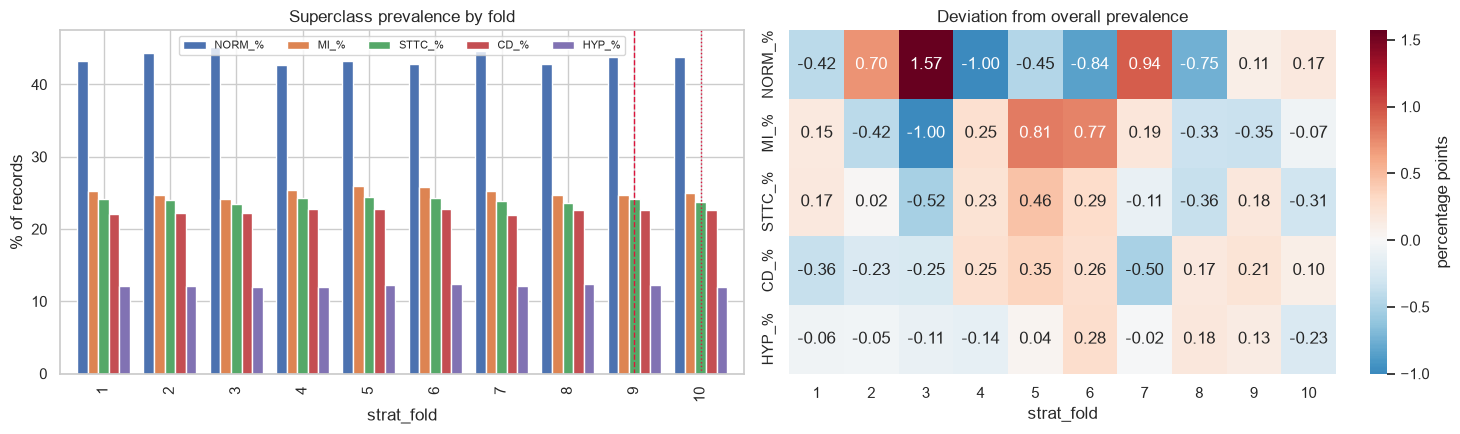

Largest absolute deviation per class (percentage points):
NORM_%    1.57
MI_%      1.00
STTC_%    0.52
CD_%      0.50
HYP_%     0.28


In [9]:
per_fold = folds.drop(index="ALL")
prevalence = per_fold[[f"{c}_%" for c in SUPERCLASSES]]
overall = folds.loc["ALL", [f"{c}_%" for c in SUPERCLASSES]].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

prevalence.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Superclass prevalence by fold")
axes[0].set_xlabel("strat_fold")
axes[0].set_ylabel("% of records")
axes[0].legend(title=None, ncol=5, fontsize=8)
for fold, style in ((VAL_FOLD, "--"), (TEST_FOLD, ":")):
    axes[0].axvline(list(per_fold.index).index(fold), color="crimson", ls=style, lw=1)

# Deviation from the overall rate makes drift legible in a way raw bars do not.
deviation = prevalence.astype(float).subtract(overall, axis=1)
sns.heatmap(deviation.T, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            ax=axes[1], cbar_kws={"label": "percentage points"})
axes[1].set_title("Deviation from overall prevalence")
axes[1].set_xlabel("strat_fold")

plt.tight_layout()
plt.show()

print("Largest absolute deviation per class (percentage points):")
print(deviation.abs().max().round(2).to_string())

## 4. Labels: multi-label structure

Three things determine how the loss and the metrics must be written: how many labels a record carries, how often classes co-occur, and how imbalanced the rare classes are.

In [10]:
label_counts = df["n_superclasses"].value_counts().sort_index()
print("Superclasses per record:")
for k, v in label_counts.items():
    print(f"  {k} label(s): {v:6,} ({100 * v / len(df):5.2f}%)")

n_unlabelled = int((df["n_superclasses"] == 0).sum())
print(f"\nRecords with NO diagnostic superclass: {n_unlabelled:,} "
      f"({100 * n_unlabelled / len(df):.2f}%)")
print("These are retained and flagged, not dropped (integrity rule 8).")
print("Decision required before training: exclude them, or treat as all-negative?")

if n_unlabelled:
    print("\nMost common SCP statements among unlabelled records:")
    unlabelled_codes = (
        df.loc[df["n_superclasses"] == 0, "scp_codes_parsed"]
        .apply(lambda d: list(d.keys()))
        .explode()
        .value_counts()
        .head(10)
    )
    print(unlabelled_codes.to_string())

Superclasses per record:
  0 label(s):    411 ( 1.89%)
  1 label(s): 16,244 (74.52%)
  2 label(s):  4,068 (18.66%)
  3 label(s):    919 ( 4.22%)
  4 label(s):    157 ( 0.72%)

Records with NO diagnostic superclass: 411 (1.89%)
These are retained and flagged, not dropped (integrity rule 8).
Decision required before training: exclude them, or treat as all-negative?

Most common SCP statements among unlabelled records:
scp_codes_parsed
PACE     284
AFIB      63
AFLT      49
ABQRS     17
PSVT      15
PVC       15
SR        14
BIGU      11
STACH      8
SVARR      6


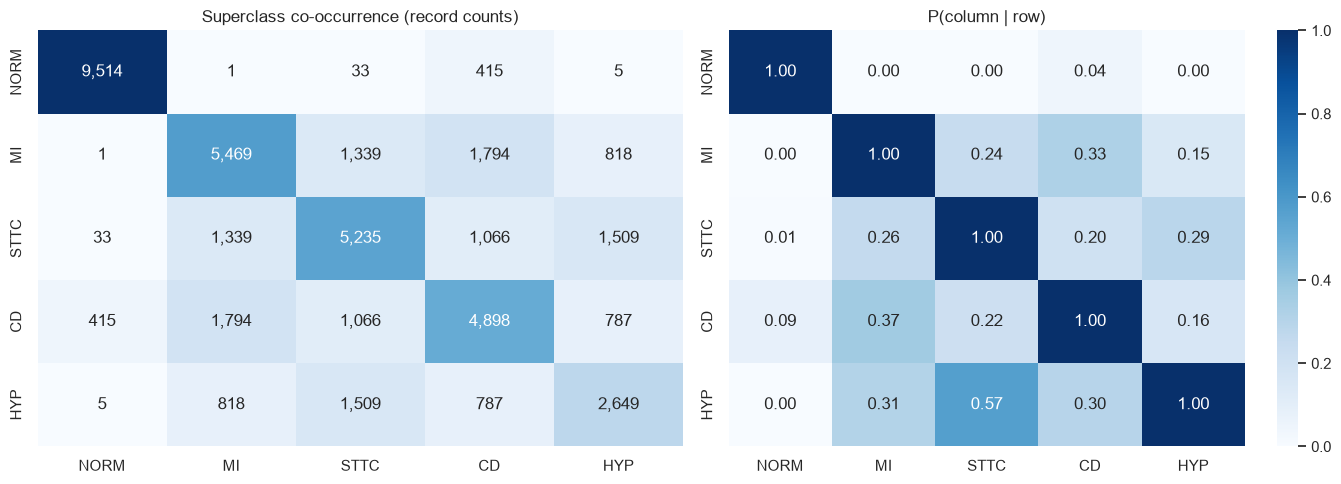

Class support (drives PR-AUC far more than AUROC):


,n_positive,prevalence_%,imbalance_ratio
NORM,9514,43.64,1.3
MI,5469,25.09,3.0
STTC,5235,24.01,3.2
CD,4898,22.47,3.5
HYP,2649,12.15,7.2


In [11]:
counts = cooccurrence_matrix(df)
conditional = cooccurrence_matrix(df, normalise=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(counts, annot=True, fmt=",d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Superclass co-occurrence (record counts)")
sns.heatmap(conditional, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("P(column | row)")
plt.tight_layout()
plt.show()

support = pd.DataFrame({
    "n_positive": [int(df[c].sum()) for c in SUPERCLASSES],
    "prevalence_%": [round(100 * float(df[c].mean()), 2) for c in SUPERCLASSES],
}, index=list(SUPERCLASSES))
support["imbalance_ratio"] = (
    (len(df) - support["n_positive"]) / support["n_positive"]
).round(1)
print("Class support (drives PR-AUC far more than AUROC):")
display(support.sort_values("n_positive", ascending=False))

In [12]:
# The likelihood field: 0.0 means "asserted without a quantified confidence",
# NOT "absent". Thresholding above 0 therefore deletes valid labels.
likelihoods = (
    df["scp_codes_parsed"].apply(lambda d: list(d.values())).explode().astype(float)
)
print("Distribution of SCP statement likelihoods:")
print(likelihoods.value_counts().sort_index().to_string())
print(f"\nshare at exactly 0.0: {100 * (likelihoods == 0).mean():.1f}%")
print("\nEffect of thresholding on the labelled-record count:")
for threshold in (0.0, 15.0, 50.0, 80.0, 100.0):
    subset = load_metadata(layout, likelihood_threshold=threshold)
    kept = int((subset["n_superclasses"] > 0).sum())
    print(f"  threshold {threshold:5.1f} -> {kept:6,} labelled "
          f"({100 * kept / len(subset):5.2f}%)")
print("\nWe keep 0.0. Any other choice must be recorded in the experiment config.")

Distribution of SCP statement likelihoods:
scp_codes_parsed
0.0      28992
10.0         1
14.0         1
15.0      1752
30.0         1
34.0         1
35.0       417
50.0      3246
80.0      2222
100.0    24374

share at exactly 0.0: 47.5%

Effect of thresholding on the labelled-record count:


  threshold   0.0 -> 21,388 labelled (98.11%)


  threshold  15.0 -> 21,375 labelled (98.05%)


  threshold  50.0 -> 20,373 labelled (93.46%)


  threshold  80.0 -> 19,053 labelled (87.40%)


  threshold 100.0 -> 17,221 labelled (79.00%)

We keep 0.0. Any other choice must be recorded in the experiment config.


## 5. Annotation provenance

Not every label carries the same evidential weight. PTB-XL records whether the report was generated by the recording device (`initial_autogenerated_report`), whether a human validated it (`validated_by_human`), which cardiologist did so (`validated_by`), and whether a second opinion was obtained (`second_opinion`).

This matters for interpretation: a model evaluated against machine-only labels is being scored on agreement with the recorder's built-in algorithm, not with clinicians. If that share differs between the training folds and fold 10, the test metric means something subtly different from the training objective.

In [13]:
print("Overall annotation provenance:")
print(annotation_provenance(df).as_series().to_string())

Overall annotation provenance:
records                                       21,799
machine-generated report               6,813 (31.3%)
human-validated                       16,056 (73.7%)
second expert opinion                     555 (2.5%)
machine-only (never human-checked)     5,743 (26.3%)
human-written (not autogenerated)     14,986 (68.7%)
distinct validators                               12


,split,n_records,machine_generated_%,human_validated_%,second_opinion_%,machine_only_%
strat_fold,,,,,,
1,train,2175,36.74,67.26,2.34,32.74
2,train,2181,37.09,66.30,2.02,33.70
3,train,2192,37.36,66.97,2.97,33.03
4,train,2174,35.97,68.12,2.44,31.88
5,train,2174,36.25,67.71,2.81,32.29
6,train,2173,39.67,64.15,2.39,35.85
7,train,2176,36.12,67.92,2.02,32.08
8,train,2173,36.08,67.79,2.25,32.21
9,val,2183,9.16,100.00,3.11,0.00


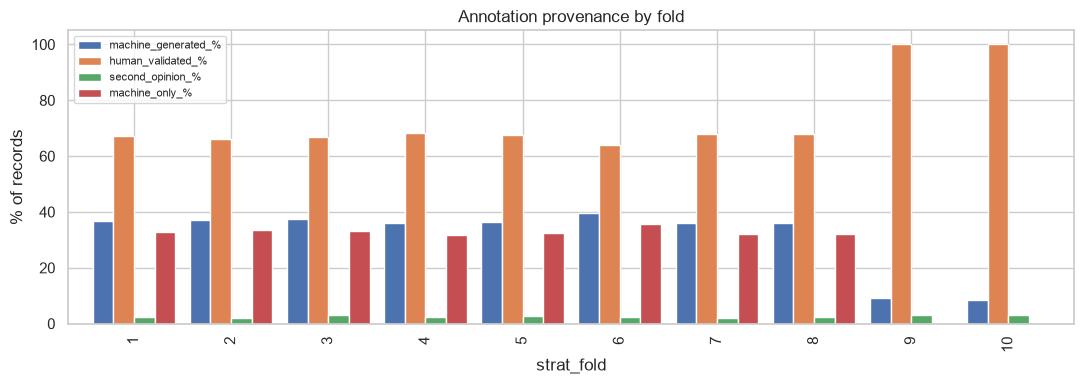

machine-only share, train folds : 32.97%
machine-only share, test fold   : 0.00%
difference                      : -32.97 percentage points

If this gap is large, report test metrics on human-validated records as a
secondary analysis — declared up front, never chosen after seeing results.


In [14]:
prov = provenance_by_fold(df)
display(prov)

fig, ax = plt.subplots(figsize=(11, 4))
prov[["machine_generated_%", "human_validated_%", "second_opinion_%", "machine_only_%"]].plot(
    kind="bar", ax=ax, width=0.85
)
ax.set_title("Annotation provenance by fold")
ax.set_xlabel("strat_fold")
ax.set_ylabel("% of records")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

train_mask = df["strat_fold"].isin(TRAIN_FOLDS)
train_only = annotation_provenance(df[train_mask])
test_only = annotation_provenance(df[df["strat_fold"] == TEST_FOLD])
gap = (100 * test_only.machine_only / test_only.total) - (
    100 * train_only.machine_only / train_only.total
)
print(f"machine-only share, train folds : {100 * train_only.machine_only / train_only.total:.2f}%")
print(f"machine-only share, test fold   : {100 * test_only.machine_only / test_only.total:.2f}%")
print(f"difference                      : {gap:+.2f} percentage points")
print("\nIf this gap is large, report test metrics on human-validated records as a")
print("secondary analysis — declared up front, never chosen after seeing results.")

In [15]:
# Does provenance correlate with the label itself? If machine-only records are
# overwhelmingly NORM, then "drop unvalidated records" would also reshape the
# class balance — a preprocessing choice with a hidden second effect.
machine_only = df["initial_autogenerated_report"].astype(bool) & ~df["validated_by_human"].astype(bool)
provenance_by_label = pd.DataFrame({
    "machine_only_%": [
        round(100 * float(machine_only[df[c]].mean()), 2) for c in SUPERCLASSES
    ],
    "n_records": [int(df[c].sum()) for c in SUPERCLASSES],
}, index=list(SUPERCLASSES))
provenance_by_label.loc["(unlabelled)"] = [
    round(100 * float(machine_only[df["n_superclasses"] == 0].mean()), 2),
    int((df["n_superclasses"] == 0).sum()),
]
print("Share of machine-only annotations within each class:")
display(provenance_by_label)

Share of machine-only annotations within each class:


,machine_only_%,n_records
NORM,17.64,9514.0
MI,36.42,5469.0
STTC,28.90,5235.0
CD,26.66,4898.0
HYP,32.16,2649.0
(unlabelled),60.83,411.0


## 6. Demographics

Age sentinel (>89 stored as 300): 293 records (1.34%)
  naive mean age    : 62.8 years  <- wrong
  corrected mean age: 59.5 years
  missing age       : 0


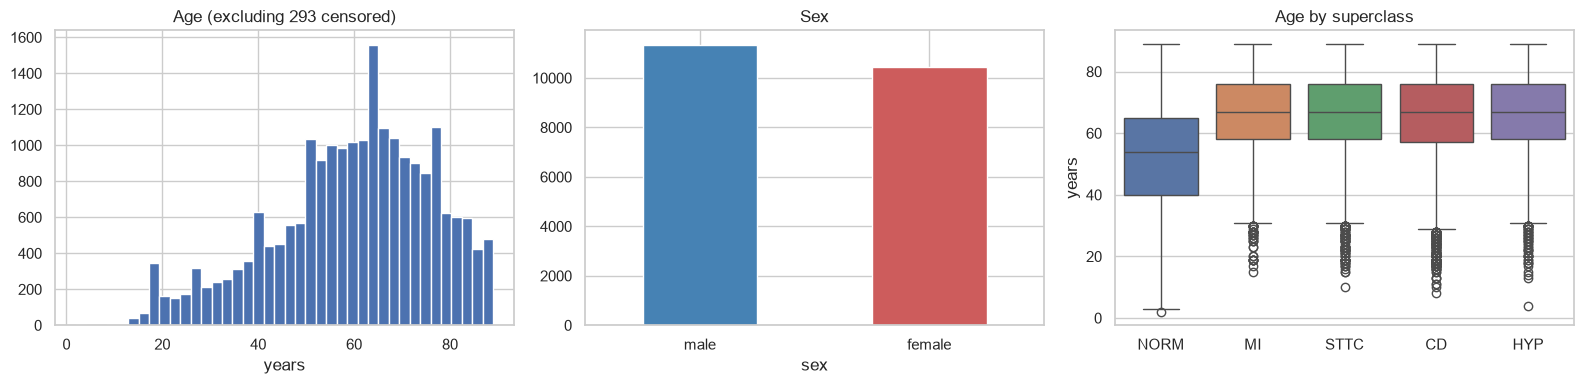

In [16]:
n_censored = int(df["age_censored"].sum())
print(f"Age sentinel (>89 stored as 300): {n_censored:,} records "
      f"({100 * n_censored / len(df):.2f}%)")
print(f"  naive mean age    : {df['age'].mean():.1f} years  <- wrong")
print(f"  corrected mean age: {df.loc[~df['age_censored'], 'age'].mean():.1f} years")
print(f"  missing age       : {int(df['age'].isna().sum()):,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

valid_age = df.loc[~df["age_censored"], "age"].dropna()
axes[0].hist(valid_age, bins=40, edgecolor="white")
axes[0].set_title(f"Age (excluding {n_censored:,} censored)")
axes[0].set_xlabel("years")

sex_labels = df["sex"].map({0: "male", 1: "female"}).fillna("unknown")
sex_labels.value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "indianred", "grey"])
axes[1].set_title("Sex")
axes[1].tick_params(axis="x", rotation=0)

age_by_class = pd.DataFrame({
    c: df.loc[df[c] & ~df["age_censored"], "age"] for c in SUPERCLASSES
})
sns.boxplot(data=age_by_class, ax=axes[2])
axes[2].set_title("Age by superclass")
axes[2].set_ylabel("years")

plt.tight_layout()
plt.show()

## 7. Signal quality flags

PTB-XL's annotators recorded which records suffer baseline drift, static noise, burst noise or electrode problems. These feed the failure manifest required by integrity rule 8 — and noisy records are exactly where R-peak detection, and therefore the RR tokenizer, is most likely to fail.

In [17]:
display(quality_flag_summary(df))

for column in ("pacemaker", "extra_beats", "heart_axis", "device"):
    if column in df.columns:
        counts = df[column].value_counts(dropna=False).head(6)
        print(f"\n{column}:")
        print(counts.to_string())

# Pacemakers matter for the RR tokenizer specifically: paced rhythms have
# regular but artificial RR intervals and atypical QRS morphology.
if "pacemaker" in df.columns:
    paced = df["pacemaker"].notna() & (df["pacemaker"].astype(str).str.strip() != "")
    print(f"\nPaced records: {int(paced.sum()):,} ({100 * paced.mean():.2f}%)")

,n_records,pct
quality_flag,,
baseline_drift,1598.0,7.33
static_noise,3260.0,14.95
burst_noise,612.0,2.81
electrodes_problems,30.0,0.14



pacemaker:
pacemaker
NaN              21508
ja, pacemaker      285
ja, nan              3
PACE????, nan        2
?, nan               1

extra_beats:
extra_beats
NaN           19850
1ES             405
SVES            381
2ES             179
VES             159
VES1,alles      151

heart_axis:
heart_axis
NaN     8468
MID     7687
LAD     3764
ALAD    1382
RAD      221
ARAD     122

device:
device
CS100    3    6140
CS-12         4048
AT-6 C 5.5    3950
CS-12   E     2878
AT-6     6    2273
AT-60    3     966

Paced records: 291 (1.33%)


## 8. Waveforms: one normal, one abnormal

All 12 leads, drawn from the **training folds only** — no eyeballing of test data.

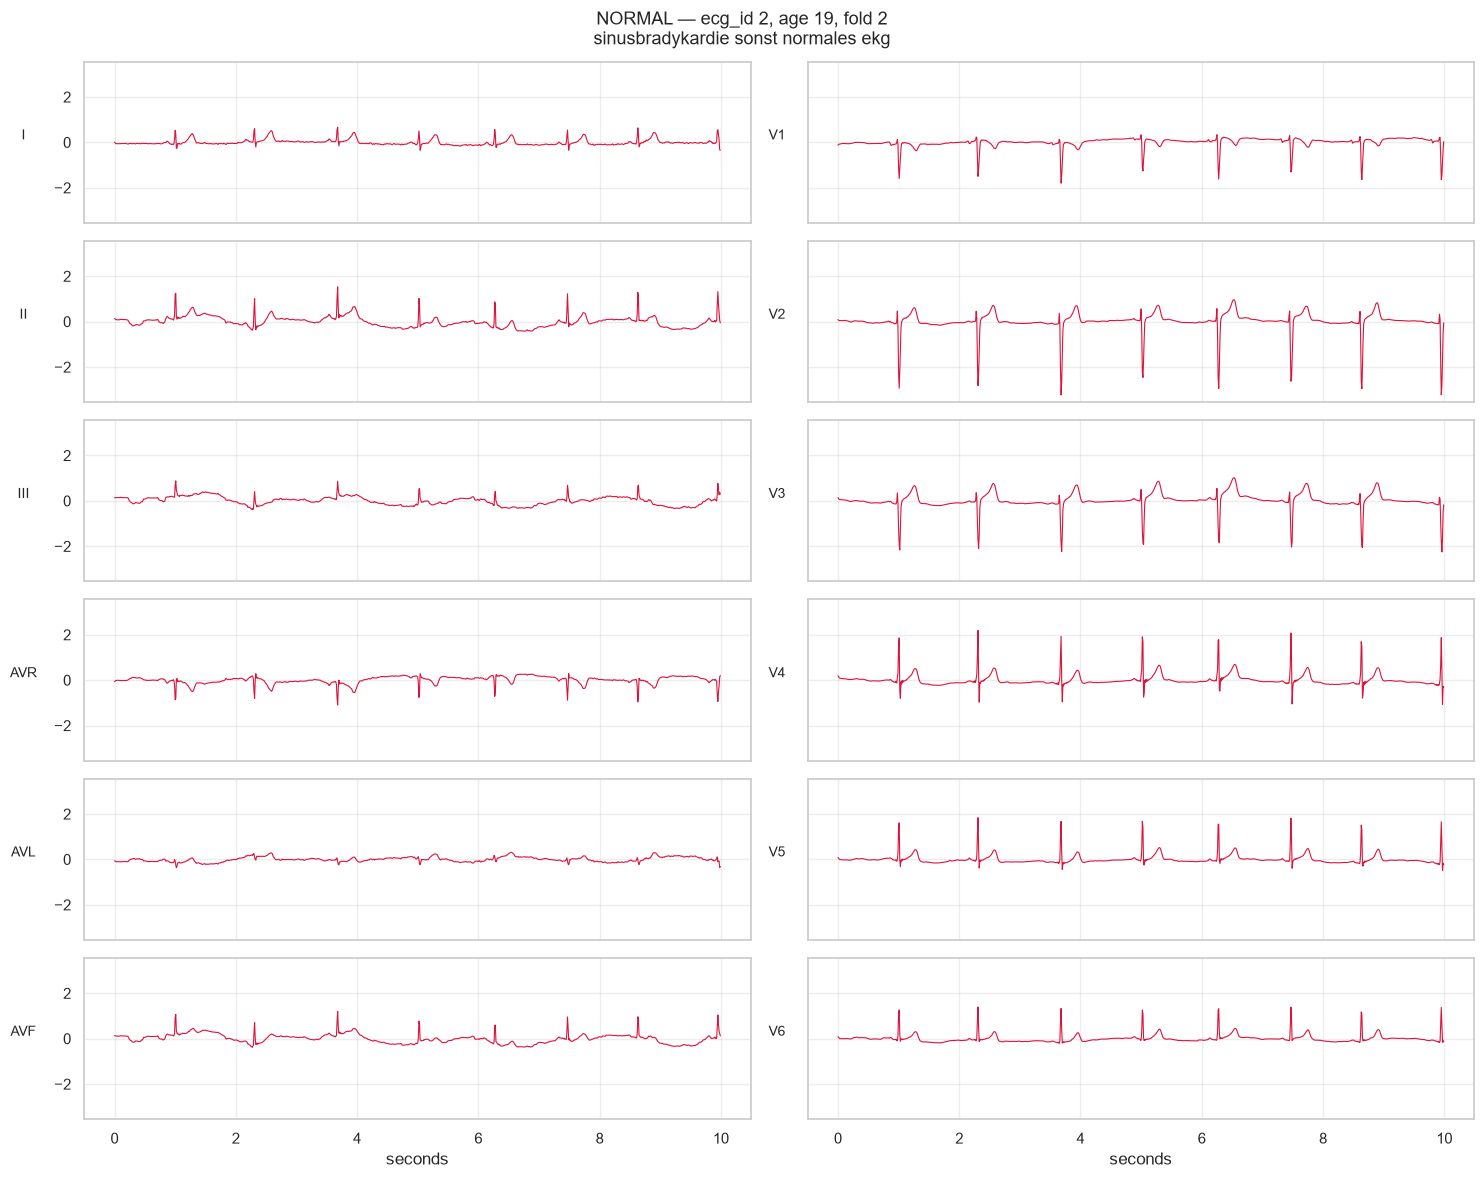

In [18]:
def plot_12_lead(
    signal: np.ndarray,
    lead_names: list[str],
    sampling_rate: int,
    title: str,
) -> None:
    """Draw a 12-lead ECG in a 6x2 grid on a shared amplitude scale.

    A shared y-axis matters clinically: lead-to-lead amplitude differences are
    diagnostic (they are what HYP is largely about), so per-lead autoscaling
    would hide the signal we care about.

    Args:
        signal: Array of shape ``(n_samples, 12)`` in mV.
        lead_names: Lead names in column order.
        sampling_rate: Sampling rate in Hz, used for the time axis.
        title: Figure title.
    """
    time = np.arange(signal.shape[0]) / sampling_rate
    limit = float(np.nanmax(np.abs(signal))) * 1.1

    fig, axes = plt.subplots(6, 2, figsize=(15, 12), sharex=True, sharey=True)
    for index, ax in enumerate(axes.T.flatten()):
        ax.plot(time, signal[:, index], lw=0.8, color="crimson")
        ax.set_ylabel(lead_names[index], rotation=0, labelpad=22, fontsize=10)
        ax.set_ylim(-limit, limit)
        ax.grid(True, which="major", alpha=0.35)
    for ax in axes[-1]:
        ax.set_xlabel("seconds")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


SAMPLING_RATE = 100
train_df = df[df["strat_fold"].isin(TRAIN_FOLDS)]

# A clean example: NORM, human-validated, no quality flags.
clean = (
    train_df["NORM"]
    & (train_df["n_superclasses"] == 1)
    & train_df["validated_by_human"].astype(bool)
    & train_df["baseline_drift"].isna()
    & train_df["static_noise"].isna()
)
normal_row = train_df[clean].iloc[0]
signal, leads = load_waveform(layout, normal_row, sampling_rate=SAMPLING_RATE)
plot_12_lead(
    signal, leads, SAMPLING_RATE,
    f"NORMAL — ecg_id {normal_row.name}, age {normal_row['age']:.0f}, "
    f"fold {normal_row['strat_fold']}\n{str(normal_row['report'])[:110]}",
)

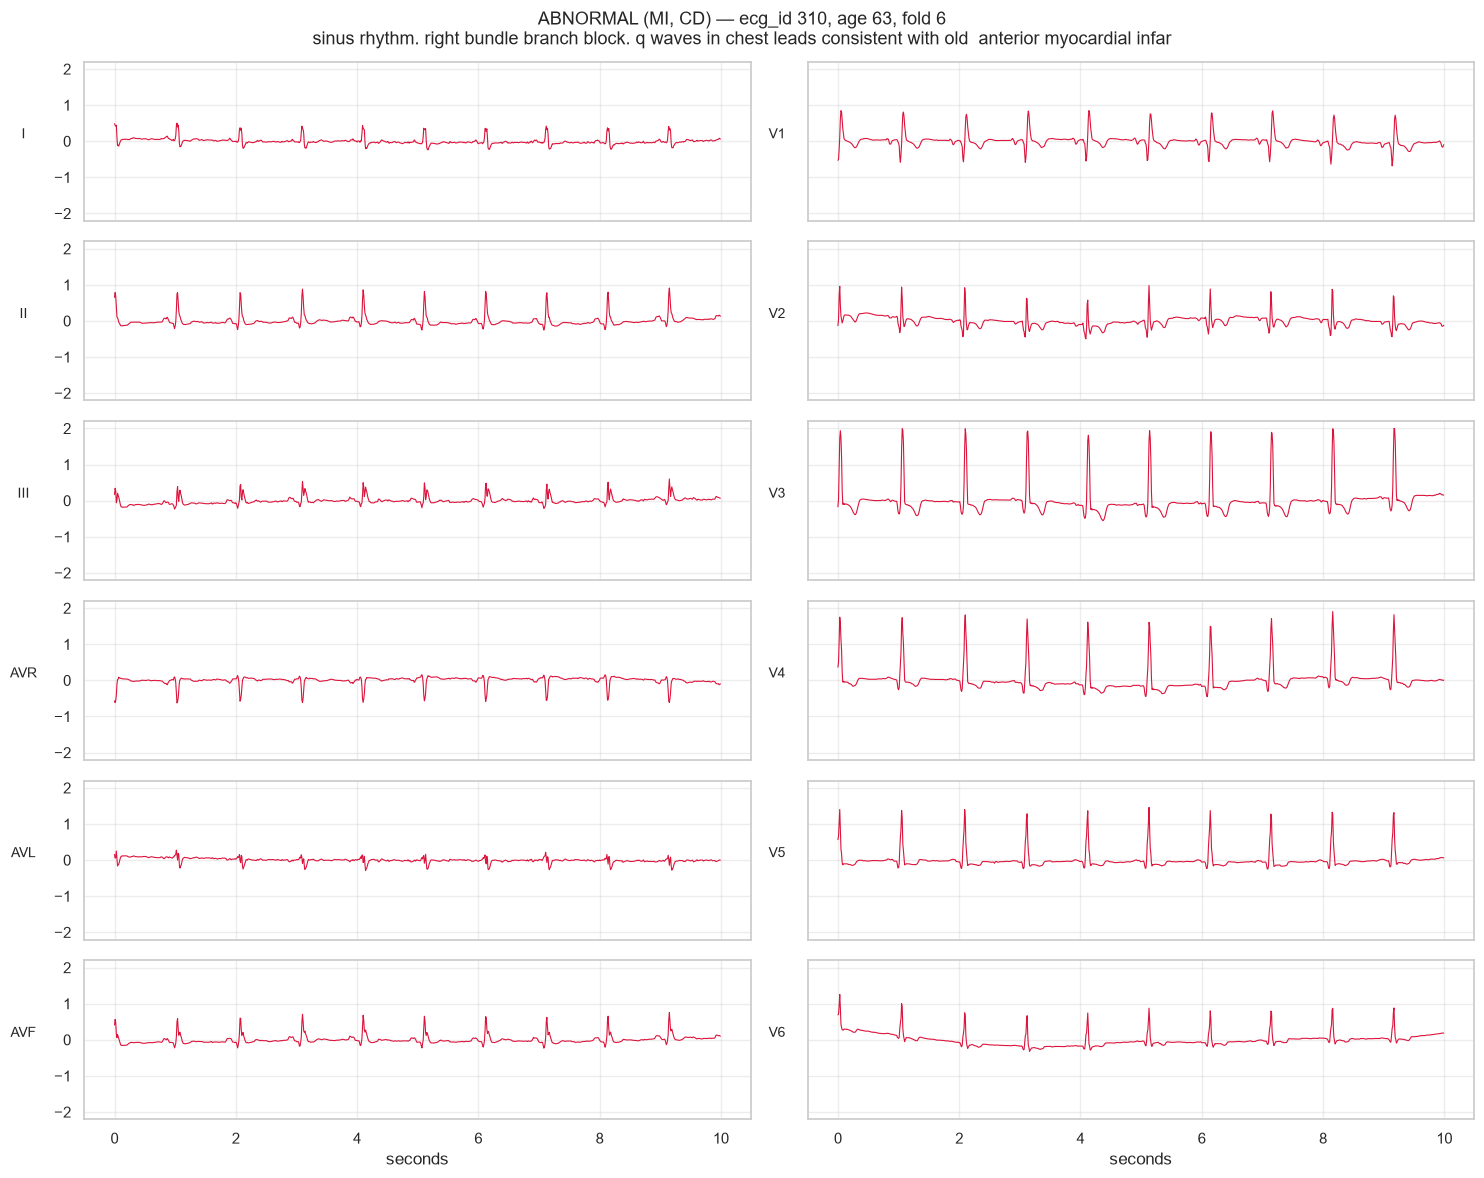

SCP statements: {'ASMI': 100.0, 'CRBBB': 100.0, 'QWAVE': 0.0, 'SR': 0.0}


In [19]:
# An abnormal example: myocardial infarction, human-validated, second opinion
# where available — the strongest available label evidence.
abnormal_mask = (
    train_df["MI"]
    & ~train_df["NORM"]
    & train_df["validated_by_human"].astype(bool)
)
candidates = train_df[abnormal_mask]
with_second = candidates[candidates["second_opinion"].astype(bool)]
abnormal_row = (with_second if len(with_second) else candidates).iloc[0]

signal, leads = load_waveform(layout, abnormal_row, sampling_rate=SAMPLING_RATE)
plot_12_lead(
    signal, leads, SAMPLING_RATE,
    f"ABNORMAL ({', '.join(abnormal_row['superclasses'])}) — "
    f"ecg_id {abnormal_row.name}, age {abnormal_row['age']:.0f}, "
    f"fold {abnormal_row['strat_fold']}\n{str(abnormal_row['report'])[:110]}",
)
print("SCP statements:", abnormal_row["scp_codes_parsed"])

## 9. 100 Hz vs 500 Hz

Direct evidence for the decision to detect R-peaks at 500 Hz regardless of the model's working resolution.

100 Hz shape: (1000, 12)   500 Hz shape: (5000, 12)


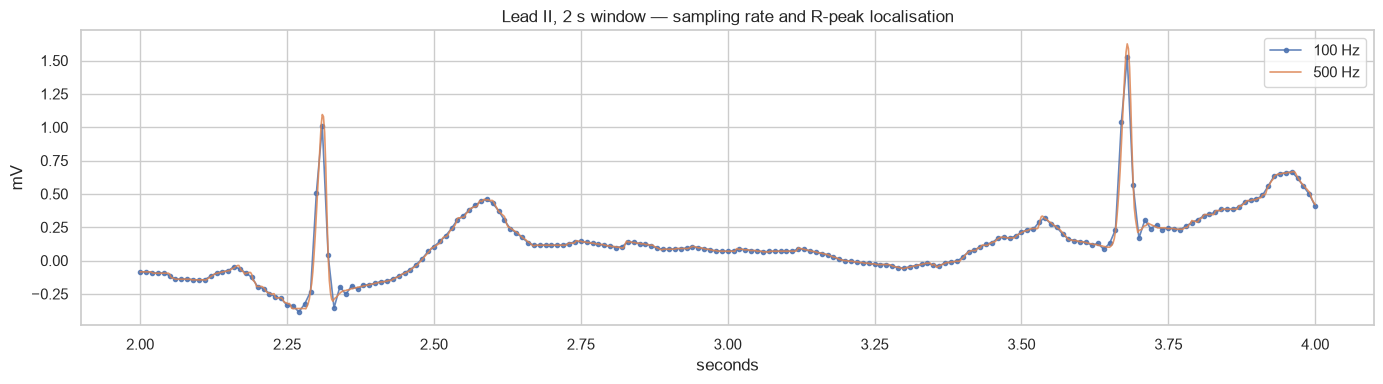

Timing resolution: 10 ms per sample at 100 Hz vs 2 ms at 500 Hz.
At 100 Hz an R-peak can only be located to the nearest 10 ms, which is a
meaningful fraction of the RR variability the beat tokenizer encodes.


In [20]:
sig_100, _ = load_waveform(layout, normal_row, sampling_rate=100)
sig_500, _ = load_waveform(layout, normal_row, sampling_rate=500)
print(f"100 Hz shape: {sig_100.shape}   500 Hz shape: {sig_500.shape}")

lead_ii = 1  # lead II: the usual choice for rhythm and R-peak work
window = (2.0, 4.0)

fig, ax = plt.subplots(figsize=(14, 4))
for signal, rate, style in ((sig_100, 100, "o-"), (sig_500, 500, "-")):
    time = np.arange(signal.shape[0]) / rate
    mask = (time >= window[0]) & (time <= window[1])
    ax.plot(time[mask], signal[mask, lead_ii], style, lw=1.2, ms=3,
            alpha=0.85, label=f"{rate} Hz")
ax.set_title("Lead II, 2 s window — sampling rate and R-peak localisation")
ax.set_xlabel("seconds")
ax.set_ylabel("mV")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Timing resolution: {1000 / 100:.0f} ms per sample at 100 Hz vs "
      f"{1000 / 500:.0f} ms at 500 Hz.")
print("At 100 Hz an R-peak can only be located to the nearest 10 ms, which is a")
print("meaningful fraction of the RR variability the beat tokenizer encodes.")

## 10. Heart rate and beats per record

This section sizes the RR tokenizer. With **1 RR interval per token**, the number of beats in a 10 s record *is* the sequence length — so its distribution determines padding, masking, and how far the RR arm's sequence length drifts from the fixed-patch arm's constant length.

Run on a sample from the training folds only. Detection uses the 500 Hz signal, per the decision above.

In [21]:
import neurokit2 as nk

SAMPLE_SIZE = 300
DETECT_RATE = 500
LEAD_II = 1

sample_ids = rng.choice(train_df.index.to_numpy(), size=SAMPLE_SIZE, replace=False)

beat_counts: list[int] = []
mean_hr: list[float] = []
all_rr: list[float] = []
failures: list[tuple[int, str]] = []

for ecg_id in sample_ids:
    row = df.loc[ecg_id]
    try:
        signal, _ = load_waveform(layout, row, sampling_rate=DETECT_RATE)
        cleaned = nk.ecg_clean(signal[:, LEAD_II], sampling_rate=DETECT_RATE)
        _, info = nk.ecg_peaks(cleaned, sampling_rate=DETECT_RATE, method="neurokit")
        peaks = np.asarray(info["ECG_R_Peaks"], dtype=float)
        if len(peaks) < 2:
            failures.append((int(ecg_id), f"only {len(peaks)} R-peaks"))
            continue
        rr = np.diff(peaks) / DETECT_RATE  # seconds
        beat_counts.append(len(peaks))
        mean_hr.append(float(60.0 / np.mean(rr)))
        all_rr.extend(rr.tolist())
    except Exception as error:  # reported, never silently skipped
        failures.append((int(ecg_id), f"{type(error).__name__}: {error}"))

print(f"processed {len(beat_counts)}/{SAMPLE_SIZE} records")
print(f"detection failures: {len(failures)} "
      f"({100 * len(failures) / SAMPLE_SIZE:.1f}%)  <- these go to the failure manifest")
for ecg_id, reason in failures[:10]:
    print(f"  ecg_id {ecg_id}: {reason}")

processed 300/300 records
detection failures: 0 (0.0%)  <- these go to the failure manifest


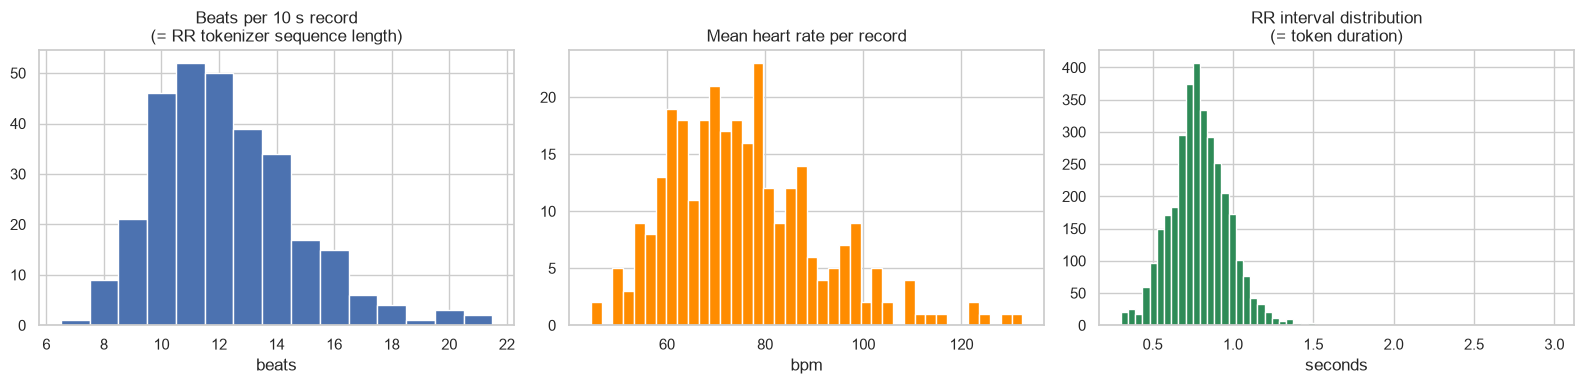

beats per record : min 7, p5 9, median 12, p95 17, max 21
heart rate (bpm) : median 73.8, p5 55.0, p95 103.4
RR interval (s)  : median 0.782, p5 0.498, p95 1.087

RR outside 300-2000 ms (physiologically implausible): 0.03%


In [22]:
beats = np.array(beat_counts)
rr_array = np.array(all_rr)
hr_array = np.array(mean_hr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(beats, bins=range(int(beats.min()), int(beats.max()) + 2),
             edgecolor="white", align="left")
axes[0].set_title("Beats per 10 s record\n(= RR tokenizer sequence length)")
axes[0].set_xlabel("beats")

axes[1].hist(hr_array, bins=40, edgecolor="white", color="darkorange")
axes[1].set_title("Mean heart rate per record")
axes[1].set_xlabel("bpm")

axes[2].hist(rr_array, bins=60, edgecolor="white", color="seagreen")
axes[2].set_title("RR interval distribution\n(= token duration)")
axes[2].set_xlabel("seconds")

plt.tight_layout()
plt.show()

print(f"beats per record : min {beats.min()}, p5 {np.percentile(beats, 5):.0f}, "
      f"median {np.median(beats):.0f}, p95 {np.percentile(beats, 95):.0f}, max {beats.max()}")
print(f"heart rate (bpm) : median {np.median(hr_array):.1f}, "
      f"p5 {np.percentile(hr_array, 5):.1f}, p95 {np.percentile(hr_array, 95):.1f}")
print(f"RR interval (s)  : median {np.median(rr_array):.3f}, "
      f"p5 {np.percentile(rr_array, 5):.3f}, p95 {np.percentile(rr_array, 95):.3f}")

implausible = ((rr_array < 0.3) | (rr_array > 2.0)).mean()
print(f"\nRR outside 300-2000 ms (physiologically implausible): {100 * implausible:.2f}%")

In [23]:
# Sequence length, the two tokenizers side by side. Fixed patches give a
# constant length by construction; RR tokens do not. This asymmetry is the
# study's subject and must be reported, not engineered away.
RECORD_SECONDS = 10.0
N_LEADS = 12

rows = []
for patch_ms in (250, 500, 800, 1000):
    n_segments = int(RECORD_SECONDS * 1000 / patch_ms)
    rows.append({
        "tokenizer": f"fixed {patch_ms} ms",
        "tokens_per_lead": f"{n_segments}",
        "total_tokens": f"{n_segments * N_LEADS}",
        "varies": "no",
    })
rows.append({
    "tokenizer": "RR (1 beat/token)",
    "tokens_per_lead": f"{np.percentile(beats, 5):.0f}-{np.percentile(beats, 95):.0f} "
                       f"(median {np.median(beats):.0f})",
    "total_tokens": f"{N_LEADS * np.percentile(beats, 5):.0f}-"
                    f"{N_LEADS * np.percentile(beats, 95):.0f} "
                    f"(median {N_LEADS * np.median(beats):.0f})",
    "varies": "YES — needs padding + attention mask",
})
display(pd.DataFrame(rows).set_index("tokenizer"))

print(f"Max sequence length to budget for: {N_LEADS * beats.max():.0f} tokens "
      f"(fastest heart rate in the sample).")

,tokens_per_lead,total_tokens,varies
tokenizer,,,
fixed 250 ms,40,480,no
fixed 500 ms,20,240,no
fixed 800 ms,12,144,no
fixed 1000 ms,10,120,no
RR (1 beat/token),9-17 (median 12),108-204 (median 144),YES — needs padding + attention mask


Max sequence length to budget for: 252 tokens (fastest heart rate in the sample).


## 11. The training cohort after cleaning

Two different cohorts, by decision:

* **SSL pretraining — every record in folds 1–8, unfiltered.** Pretraining needs no labels, so weak, absent or self-contradictory annotation is irrelevant to it, and paced or noisy recordings are still perfectly good signal to learn representations from. Folds 9 and 10 are excluded outright: pretraining on held-out waveforms would leak them into the model.

* **Supervised training — folds 1–8, minus five categories:**

  | Reason | Concern |
  |---|---|
  | `pacemaker` | artificial RR regularity and atypical QRS — unrepresentative input for a beat tokenizer |
  | `electrodes_problems` | the recording itself is suspect |
  | `not_validated_by_human` | label never checked by a cardiologist — weak supervision |
  | `unlabelled` | no diagnostic superclass, so no training signal for a 5-class target |
  | `norm_with_pathology` | annotated `NORM` *and* a pathology — the two assertions contradict each other and there is no way to tell which is wrong |

The filter applies to the **training split only**. Validation and test keep every record, so the held-out metrics keep describing the population the model will actually meet rather than a tidier one. Everything removed goes to a manifest rather than vanishing (integrity rule 8).

This section re-runs the §3–§5 statistics on the cleaned cohort, so the cost of the decision is visible and recorded rather than discovered later.

In [24]:
from ecg.data.ptbxl import (
    apply_supervised_filter,
    exclusion_summary,
    ssl_pretraining_pool,
)

# What each reason removes, per split. Reasons overlap, so the per-reason
# columns do not sum to excluded_any.
print("What the filter would remove from each split:")
display(exclusion_summary(df))

# Applied for real: training split only.
clean_df, manifest = apply_supervised_filter(df, splits=("train",))

raw_train = df[df["split"] == "train"]
clean_train = clean_df[clean_df["split"] == "train"]
ssl_pool = ssl_pretraining_pool(df)

print(f"SSL pretraining pool (folds 1-8, unfiltered) : {len(ssl_pool):,} records")
print(f"supervised train, before                     : {len(raw_train):,} records, "
      f"{raw_train['patient_id'].nunique():,} patients")
print(f"supervised train, after                      : {len(clean_train):,} records, "
      f"{clean_train['patient_id'].nunique():,} patients")
print(f"removed                                      : {len(raw_train) - len(clean_train):,} "
      f"({100 * (1 - len(clean_train) / len(raw_train)):.1f}%)")
print(f"val / test                                   : untouched "
      f"({int((clean_df['split'] == 'val').sum()):,} / "
      f"{int((clean_df['split'] == 'test').sum()):,})")

print("\nExclusion manifest, by reason combination (train only):")
print(manifest["reasons"].value_counts().to_string())
print(f"\nmanifest rows: {len(manifest):,} — saved with the run, per integrity rule 8")
display(manifest.head())

What the filter would remove from each split:


,n_records,pacemaker,electrodes_problems,not_validated_by_human,unlabelled,norm_with_pathology,excluded_any,retained,retained_%
split,,,,,,,,,
train,17418.0,234.0,23.0,5743.0,334.0,353.0,6157.0,11261.0,64.65
val,2183.0,28.0,4.0,0.0,37.0,41.0,84.0,2099.0,96.15
test,2198.0,29.0,3.0,0.0,40.0,51.0,95.0,2103.0,95.68


SSL pretraining pool (folds 1-8, unfiltered) : 17,418 records
supervised train, before                     : 17,418 records, 15,023 patients
supervised train, after                      : 11,261 records, 10,255 patients
removed                                      : 6,157 (35.3%)
val / test                                   : untouched (2,183 / 2,198)

Exclusion manifest, by reason combination (train only):
reasons
not_validated_by_human                         5438
norm_with_pathology                             300
pacemaker+not_validated_by_human+unlabelled     191
not_validated_by_human+unlabelled                59
not_validated_by_human+norm_with_pathology       53
unlabelled                                       51
pacemaker+unlabelled                             32
electrodes_problems                              21
pacemaker                                         9
pacemaker+electrodes_problems+unlabelled          1
pacemaker+not_validated_by_human                  1
electrode

,strat_fold,split,superclasses,reasons
ecg_id,,,,
235,4,train,"NORM,CD",norm_with_pathology
236,2,train,"NORM,CD",norm_with_pathology
251,5,train,NORM,electrodes_problems
291,1,train,"NORM,CD",norm_with_pathology
362,2,train,"NORM,CD",norm_with_pathology


In [25]:
# Per-fold statistics on the cleaned cohort (§3 repeated after filtering).
print("Per-fold statistics AFTER cleaning (train folds filtered, 9/10 untouched):")
display(fold_summary(clean_df))

print("Superclasses per record, cleaned training split:")
clean_counts = clean_train["n_superclasses"].value_counts().sort_index()
for k, v in clean_counts.items():
    print(f"  {k} label(s): {v:6,} ({100 * v / len(clean_train):5.2f}%)")

print(f"\nUnlabelled remaining in cleaned training split: "
      f"{int((clean_train['n_superclasses'] == 0).sum())} "
      f"(was {int((raw_train['n_superclasses'] == 0).sum()):,})")
norm_conflict_left = int(
    (clean_train["NORM"] & clean_train[["MI", "STTC", "CD", "HYP"]].any(axis=1)).sum()
)
print(f"NORM+pathology remaining in cleaned training split: {norm_conflict_left} "
      f"(was {int((raw_train['NORM'] & raw_train[['MI','STTC','CD','HYP']].any(axis=1)).sum())})")
print("\nBoth categories are now fully removed from training. Note that val and")
print("test still contain them, by design — see the caveat at the end of §11.")

Per-fold statistics AFTER cleaning (train folds filtered, 9/10 untouched):


,split,n_records,n_patients,unlabelled,mean_labels,NORM_%,MI_%,STTC_%,CD_%,HYP_%
strat_fold,,,,,,,,,,
1,train,1413,1296,0,1.254,49.89,20.45,23.99,19.25,11.82
2,train,1400,1255,0,1.265,50.36,20.93,23.43,20.50,11.29
3,train,1410,1279,0,1.244,48.37,21.63,23.83,20.00,10.57
4,train,1433,1308,0,1.253,49.48,20.52,24.84,20.66,9.84
5,train,1421,1290,0,1.276,49.96,22.03,23.50,20.55,11.54
6,train,1342,1240,0,1.273,51.12,21.46,22.35,21.16,11.25
7,train,1420,1282,0,1.278,50.35,21.62,22.04,21.62,12.18
8,train,1422,1305,0,1.243,48.95,20.04,23.42,20.60,11.25
9,val,2183,1942,37,1.276,43.75,24.74,24.19,22.68,12.28


Superclasses per record, cleaned training split:
  1 label(s):  8,969 (79.65%)
  2 label(s):  1,736 (15.42%)
  3 label(s):    468 ( 4.16%)
  4 label(s):     88 ( 0.78%)

Unlabelled remaining in cleaned training split: 0 (was 334)
NORM+pathology remaining in cleaned training split: 0 (was 353)

Both categories are now fully removed from training. Note that val and
test still contain them, by design — see the caveat at the end of §11.


Class prior: cleaned training split vs untouched test fold


,train_raw_%,train_clean_%,test_%,clean_minus_test_pp,raw_minus_test_pp
NORM,43.61,49.80,43.81,5.99,-0.20
MI,25.14,21.08,25.02,-3.94,0.12
STTC,24.03,23.43,23.70,-0.27,0.33
CD,22.43,20.54,22.57,-2.03,-0.14
HYP,12.17,11.22,11.92,-0.70,0.25


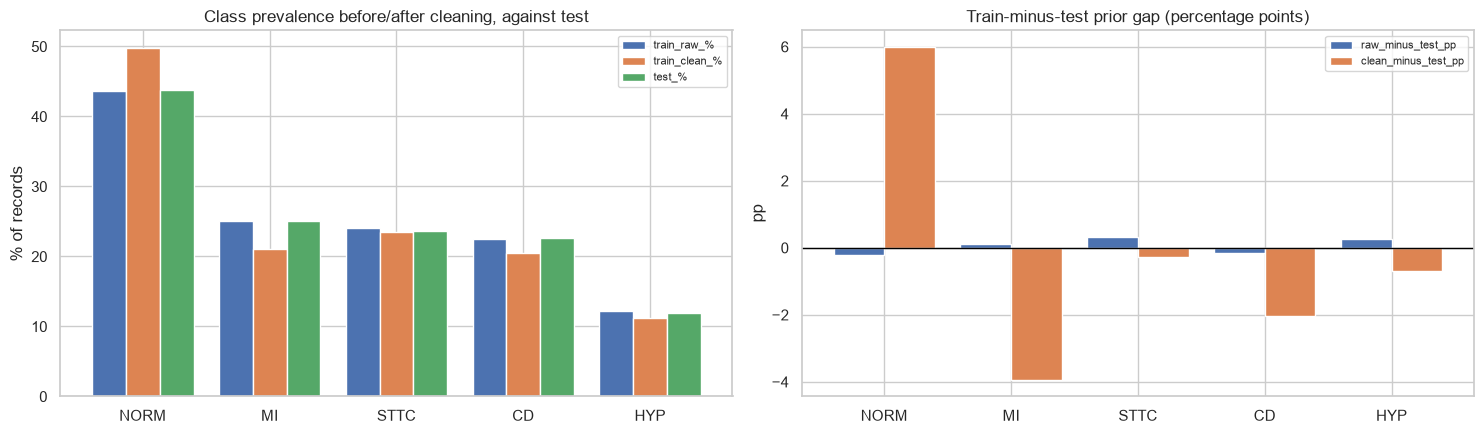

Largest prior gap after cleaning: 5.99 pp (was 0.33 pp before).

This is the price of the filter, and it is real: the model now trains on a
distribution measurably healthier than the one it is scored on. Two things
keep it from being a silent problem --
  1. per-class F1 thresholds are selected on fold 9, which is NOT filtered,
     so threshold selection sees the true prior and corrects for the shift;
  2. AUROC and PR-AUC are threshold-free and rank-based, so they are far
     less sensitive to a prior shift than raw probabilities would be.
It applies identically to all four arms, so the A/B/C/D comparison stays fair.


In [26]:
# The cost of the filter: it shifts the training class prior away from test.
# Because machine-only labels are commoner on pathology than on NORM (§5),
# removing them makes the training set look healthier than the world does.
raw_test = df[df["split"] == "test"]

shift = pd.DataFrame({
    "train_raw_%": [round(100 * float(raw_train[c].mean()), 2) for c in SUPERCLASSES],
    "train_clean_%": [round(100 * float(clean_train[c].mean()), 2) for c in SUPERCLASSES],
    "test_%": [round(100 * float(raw_test[c].mean()), 2) for c in SUPERCLASSES],
}, index=list(SUPERCLASSES))
shift["clean_minus_test_pp"] = (shift["train_clean_%"] - shift["test_%"]).round(2)
shift["raw_minus_test_pp"] = (shift["train_raw_%"] - shift["test_%"]).round(2)

print("Class prior: cleaned training split vs untouched test fold")
display(shift)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

shift[["train_raw_%", "train_clean_%", "test_%"]].plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Class prevalence before/after cleaning, against test")
axes[0].set_ylabel("% of records")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8)

shift[["raw_minus_test_pp", "clean_minus_test_pp"]].plot(kind="bar", ax=axes[1], width=0.8)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Train-minus-test prior gap (percentage points)")
axes[1].set_ylabel("pp")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

worst = shift["clean_minus_test_pp"].abs().max()
print(f"Largest prior gap after cleaning: {worst:.2f} pp "
      f"(was {shift['raw_minus_test_pp'].abs().max():.2f} pp before).")
print()
print("This is the price of the filter, and it is real: the model now trains on a")
print("distribution measurably healthier than the one it is scored on. Two things")
print("keep it from being a silent problem --")
print("  1. per-class F1 thresholds are selected on fold 9, which is NOT filtered,")
print("     so threshold selection sees the true prior and corrects for the shift;")
print("  2. AUROC and PR-AUC are threshold-free and rank-based, so they are far")
print("     less sensitive to a prior shift than raw probabilities would be.")
print("It applies identically to all four arms, so the A/B/C/D comparison stays fair.")

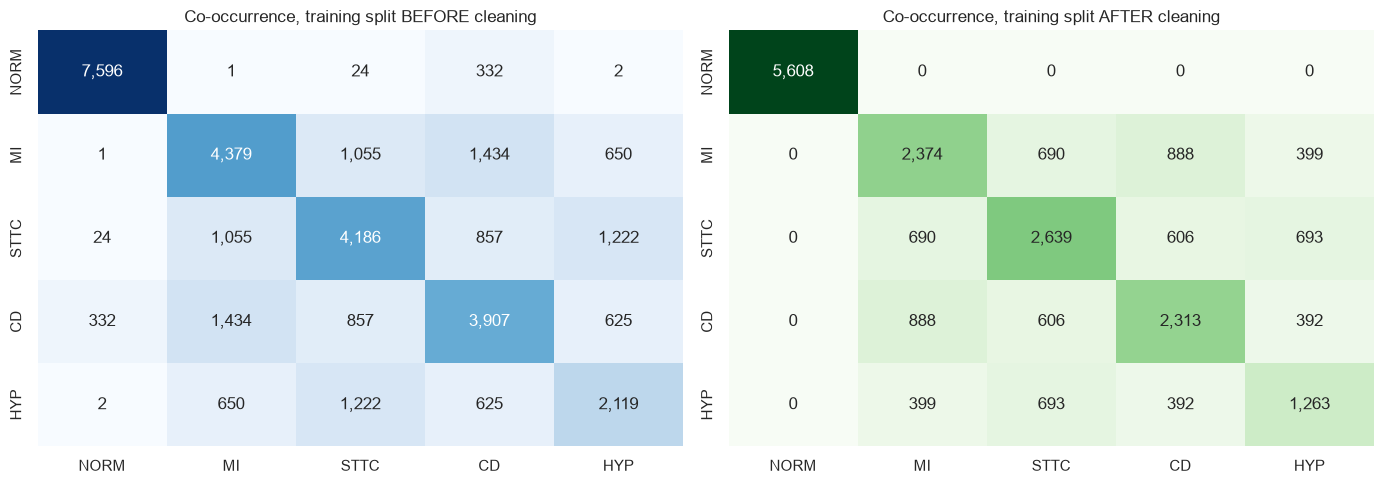

Provenance of the cleaned training split (should be 100% human-validated):
records                                        11,261
machine-generated report                   662 (5.9%)
human-validated                       11,261 (100.0%)
second expert opinion                      374 (3.3%)
machine-only (never human-checked)           0 (0.0%)
human-written (not autogenerated)      10,599 (94.1%)
distinct validators                                11

PACE as an SCP statement : 294 records
pacemaker metadata column: 291 records
  PACE-coded but no pacemaker annotation: 9 <- these survive the current filter
  pacemaker annotation but no PACE code : 6

Paced-by-SCP-code records still in the cleaned training split: 8
Open question: widen the rule to 'pacemaker column OR PACE statement'?


In [27]:
# Co-occurrence and provenance on the cleaned cohort, plus one gap worth knowing.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cooccurrence_matrix(raw_train), annot=True, fmt=",d", cmap="Blues",
            ax=axes[0], cbar=False)
axes[0].set_title("Co-occurrence, training split BEFORE cleaning")
sns.heatmap(cooccurrence_matrix(clean_train), annot=True, fmt=",d", cmap="Greens",
            ax=axes[1], cbar=False)
axes[1].set_title("Co-occurrence, training split AFTER cleaning")
plt.tight_layout()
plt.show()

print("Provenance of the cleaned training split (should be 100% human-validated):")
print(annotation_provenance(clean_train).as_series().to_string())

# The pacemaker rule keys off the metadata column. The SCP statement PACE is a
# separate annotation, and the two do not perfectly agree -- so a handful of
# paced records survive the filter. Reported rather than quietly patched
# (integrity rule 7): changing the rule is a decision, not a bugfix.
pace_code = df["scp_codes_parsed"].apply(lambda codes: "PACE" in codes)
pace_meta = df["pacemaker"].notna() & (df["pacemaker"].astype(str).str.strip() != "")
print(f"\nPACE as an SCP statement : {int(pace_code.sum()):,} records")
print(f"pacemaker metadata column: {int(pace_meta.sum()):,} records")
print(f"  PACE-coded but no pacemaker annotation: {int((pace_code & ~pace_meta).sum())} "
      f"<- these survive the current filter")
print(f"  pacemaker annotation but no PACE code : {int((pace_meta & ~pace_code).sum())}")
survivors = int((pace_code & ~pace_meta & (df['split'] == 'train')).sum())
print(f"\nPaced-by-SCP-code records still in the cleaned training split: {survivors}")
print("Open question: widen the rule to 'pacemaker column OR PACE statement'?")

In [28]:
# What the NORM+pathology conflicts actually are. Worth inspecting rather than
# assuming: if they were random annotation noise they would be spread across
# pathologies and concentrated among unvalidated records.
from ecg.data.ptbxl import supervised_exclusion_mask

mask = supervised_exclusion_mask(df)
conflict = mask["norm_with_pathology"]

print(f"NORM + pathology, dataset-wide: {int(conflict.sum()):,} records\n")
combos = df.loc[conflict, "superclasses"].apply(lambda s: "+".join(s)).value_counts()
print(combos.to_string())

share_cd = 100 * combos.get("NORM+CD", 0) / int(conflict.sum())
validated = _validated = df.loc[conflict, "validated_by_human"].astype(bool)
print(f"\nNORM+CD alone accounts for {share_cd:.1f}% of all conflicts.")
print(f"Human-validated among conflicts: {int(validated.sum()):,} / {int(conflict.sum()):,} "
      f"({100 * validated.mean():.1f}%)")
print()
print("Read that carefully. These are NOT sloppy machine labels: 88% were signed")
print("off by a cardiologist, and 91% are the single combination NORM+CD. That")
print("pattern says the annotators meant something specific — most likely 'normal")
print("ECG apart from a conduction finding' (incomplete RBBB, axis deviation, and")
print("similar), which is a routine clinical reading rather than a contradiction.")
print()
print("We exclude them anyway, by decision: for a 5-class multi-label target,")
print("NORM and a pathology on the same record give the model two incompatible")
print("gradients, and we cannot tell which label to trust. But this is a")
print("judgement call about the label space, not the removal of bad data, and it")
print("is recorded as such. Excluding NORM+CD specifically is what makes the CD")
print("prior in §11 move by -2 pp.")

print("\nBy split:")
print(df.loc[conflict].groupby("split").size().to_string())

NORM + pathology, dataset-wide: 445 records

superclasses
NORM+CD           407
NORM+STTC          28
NORM+STTC+CD        5
NORM+CD+HYP         2
NORM+HYP            2
NORM+MI+CD+HYP      1

NORM+CD alone accounts for 91.5% of all conflicts.
Human-validated among conflicts: 392 / 445 (88.1%)

Read that carefully. These are NOT sloppy machine labels: 88% were signed
off by a cardiologist, and 91% are the single combination NORM+CD. That
pattern says the annotators meant something specific — most likely 'normal
ECG apart from a conduction finding' (incomplete RBBB, axis deviation, and
similar), which is a routine clinical reading rather than a contradiction.

We exclude them anyway, by decision: for a 5-class multi-label target,
NORM and a pathology on the same record give the model two incompatible
gradients, and we cannot tell which label to trust. But this is a
judgement call about the label space, not the removal of bad data, and it
is recorded as such. Excluding NORM+CD specifically

In [29]:
# The caveat that follows from filtering train but not test: the held-out folds
# still contain records whose labels we have just declared unusable.
held_out = df["split"].isin(["val", "test"])
n_conflict_heldout = int(mask.loc[held_out, "norm_with_pathology"].sum())
n_unlabelled_heldout = int(mask.loc[held_out, "unlabelled"].sum())

print(f"Still present in val + test ({int(held_out.sum()):,} records):")
print(f"  NORM+pathology contradictions : {n_conflict_heldout}")
print(f"  unlabelled (no superclass)    : {n_unlabelled_heldout}")
print(f"  combined                      : "
      f"{int(mask.loc[held_out, ['norm_with_pathology', 'unlabelled']].any(axis=1).sum())} "
      f"({100 * mask.loc[held_out, ['norm_with_pathology', 'unlabelled']].any(axis=1).mean():.2f}%)")
print()
print("So the model will be scored against ~4% of records carrying labels the")
print("training cohort treats as invalid. Unlabelled records score as all-negative")
print("and contradictory ones are unwinnable by construction, which puts a small")
print("ceiling on every arm's metrics.")
print()
print("This is deliberate: filtering the test set would make the held-out number")
print("describe a cleaner world than the real one. The ceiling applies equally to")
print("A, B, C and D, so it cannot favour either tokenizer — it only means the")
print("absolute metrics are not comparable to papers that filtered their test set.")
print("Worth stating explicitly whenever these numbers are reported.")

Still present in val + test (4,381 records):
  NORM+pathology contradictions : 92
  unlabelled (no superclass)    : 77
  combined                      : 169 (3.86%)

So the model will be scored against ~4% of records carrying labels the
training cohort treats as invalid. Unlabelled records score as all-negative
and contradictory ones are unwinnable by construction, which puts a small
ceiling on every arm's metrics.

This is deliberate: filtering the test set would make the held-out number
describe a cleaner world than the real one. The ceiling applies equally to
A, B, C and D, so it cannot favour either tokenizer — it only means the
absolute metrics are not comparable to papers that filtered their test set.
Worth stating explicitly whenever these numbers are reported.


## 12. Decisions made, and what is still open

### Settled

| Decision | Value |
|---|---|
| Labels | 5 diagnostic superclasses, multi-label |
| Splits | published `strat_fold` verbatim — 1–8 train, 9 val, 10 test |
| SCP likelihood threshold | `0.0` (keep every asserted statement) |
| SSL pretraining cohort | **all** records in folds 1–8, unfiltered; folds 9/10 excluded |
| Supervised training cohort | folds 1–8 minus `pacemaker`, `electrodes_problems`, `not validated_by_human`, `unlabelled`, `NORM+pathology` |
| Filter scope | training split only; val and test stay whole |
| R-peak detection | NeuroKit2 on the 500 Hz signal, indices mapped down |
| RR tokenizer | 1 RR interval per token, resampled to the fixed patch length |
| Lead handling | one token per (segment × lead), 12× sequence |
| SSL objective | masked reconstruction, MSE, whole-time-column masking |
| Max sequence length | 252 tokens, padding + attention mask for the RR arm |

### Still open

1. **Signal normalization** — deferred by request. Statistics must come from the training folds only (integrity rule 2).

2. **Fixed patch duration** — 500 ms proposed; §10 shows what each choice costs in sequence length relative to the RR arm.

3. **The PACE gap (§11)** — the filter keys off the `pacemaker` metadata column, but 8 records carrying the `PACE` SCP statement without it survive into the cleaned training split. Widen the rule, or leave it and report? Either is defensible; silently changing it later would not be.

4. **Whether NORM+CD really is a contradiction (§11)** — 91.5% of the excluded conflicts are this one combination, and 88.1% were human-validated, which suggests a deliberate clinical reading rather than an annotation error. Excluding them costs 407 training records and moves the CD prior by −2 pp. An alternative worth considering is dropping the NORM label and keeping the record as CD-positive, rather than discarding the tracing entirely. Current choice: exclude, and say so.

### Consequences to carry into reporting

* Training and held-out folds no longer share a class prior (+5.99 pp on NORM). Threshold selection on the unfiltered fold 9 absorbs most of this; it should still be stated.
* ~3.9% of held-out records carry labels the training cohort treats as invalid, putting a small ceiling on every arm's metrics. Absolute values are therefore not comparable with published numbers that filtered their test sets — only the A/B and C/D contrasts are.